In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as DataLoader
from torchvision import datasets,transforms

In [2]:
train="/kaggle/input/datasets/amrragababdelaziz/dermnet-and-skin-disease-9-classes/Merged Dataset/Train"
test="/kaggle/input/datasets/amrragababdelaziz/dermnet-and-skin-disease-9-classes/Merged Dataset/test"

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms


In [5]:
from torch.utils.data import DataLoader, random_split,WeightedRandomSampler

In [6]:
import random
from torchvision import datasets, transforms


In [7]:
full_dataset = datasets.ImageFolder(train)

In [8]:
len(full_dataset)

26642

In [9]:
test_dataset=datasets.ImageFolder(test)

In [10]:
len(test_dataset)

2389

/tmp/ipykernel_57/3627464764.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()       # 🔥 Adjust layout so labels fit nicely


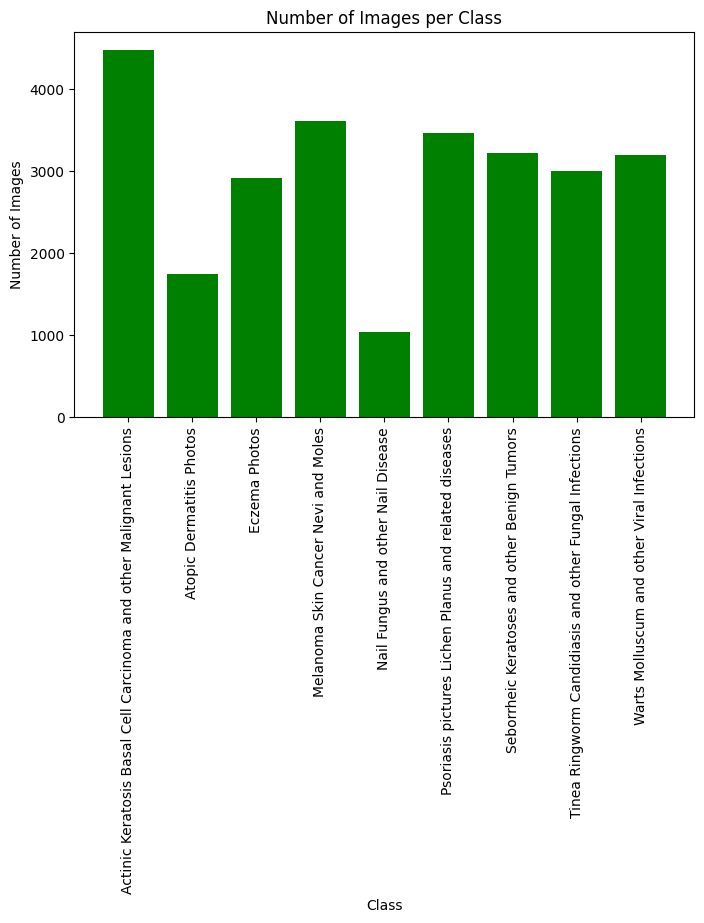

In [25]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# -------------------
# Dataset
# -------------------
transform = transforms.Compose([transforms.Resize((224,224))])
dataset = datasets.ImageFolder(train, transform=transform)  # make sure "train" is string path

# -------------------
# Count images per class
# -------------------
class_counts = {}
for label in dataset.targets:  # dataset.targets has class indices
    class_name = dataset.classes[label]
    if class_name in class_counts:
        class_counts[class_name] += 1
    else:
        class_counts[class_name] = 1

# -------------------
# Plot histogram / bar chart
# -------------------
plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values(), color='green')
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class")
plt.xticks(rotation=90)  # 🔥 Rotate class names by 90 degrees
plt.tight_layout()       # 🔥 Adjust layout so labels fit nicely
plt.show()

In [54]:
import random
from torchvision import datasets, transforms

In [27]:
import random
import math
import matplotlib.pyplot as plt

num_images = 15  # how many random images you want

# 🔥 Generate random indices
random_indices = random.sample(range(len(full_dataset)), num_images)

cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(30, 10))

for i, idx in enumerate(random_indices):
    image, label = full_dataset[idx]
    img = image.permute(1, 2, 0)

    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis('off')

plt.tight_layout()
plt.show()

AttributeError: 'Image' object has no attribute 'permute'

<Figure size 3000x1000 with 0 Axes>

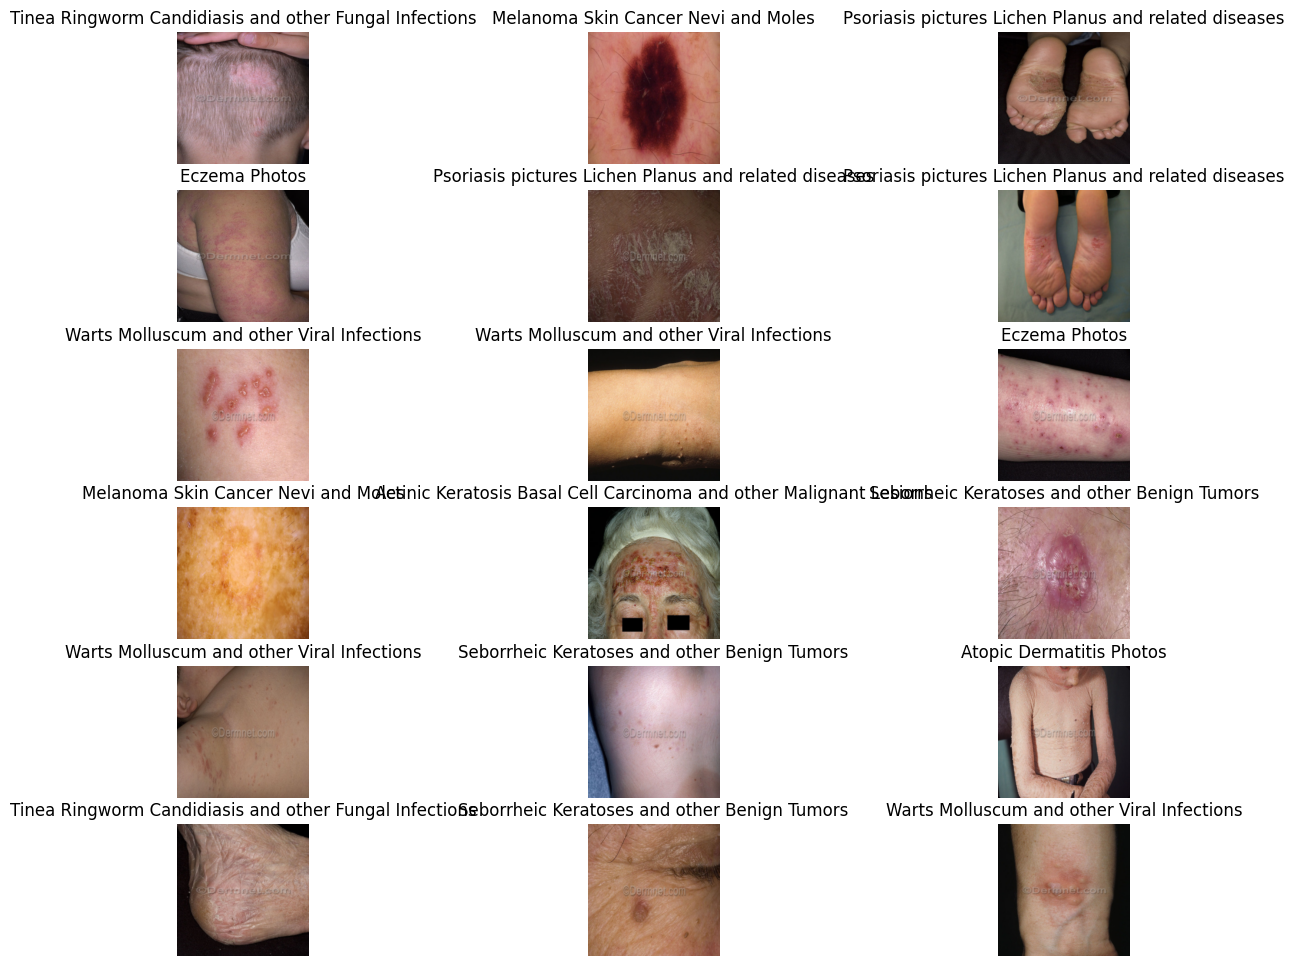

In [11]:
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(root=train, transform=train_transform)

class_names = train_data.classes
num_images = 18
random_indices = random.sample(range(len(train_data)), num_images)

plt.figure(figsize=(15, 12))

for i, idx in enumerate(random_indices):
    image, label = train_data[idx]

    img = image.permute(1, 2, 0)  # C,H,W → H,W,C

    plt.subplot(6, 3, i+1)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis('off')

plt.show()

In [56]:
def get_class_counts(dataset, classes):
    counts = {cls: 0 for cls in classes}
    
    if hasattr(dataset, 'targets'):  # for ImageFolder
        for label in dataset.targets:
            counts[classes[label]] += 1
    else:
        # for random_split (Subset)
        for idx in dataset.indices:
            label = dataset.dataset.targets[idx]
            counts[classes[label]] += 1
            
    return counts

In [57]:
# Train + Val from split
train_counts = get_class_counts(train_dataset, dataset.classes)
val_counts = get_class_counts(val_dataset, dataset.classes)
test_counts = get_class_counts(test_dataset, test_dataset.classes)

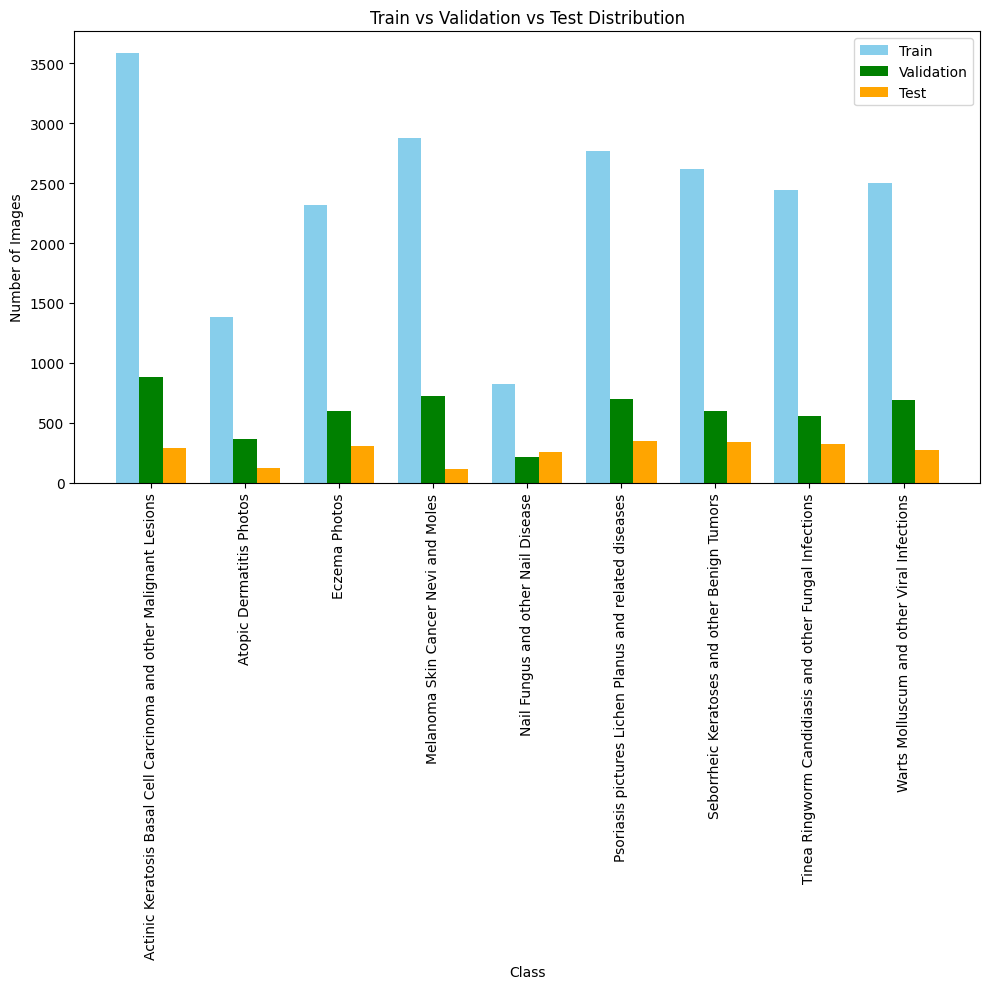

In [76]:
import numpy as np
import matplotlib.pyplot as plt

classes = dataset.classes
x = np.arange(len(classes))  # positions
width = 0.25

train_vals = [train_counts[c] for c in classes]
val_vals = [val_counts[c] for c in classes]
test_vals = [test_counts[c] for c in classes]

plt.figure(figsize=(10,10))

plt.bar(x - width, train_vals, width, label='Train', color='skyblue')
plt.bar(x, val_vals, width, label='Validation', color='green')
plt.bar(x + width, test_vals, width, label='Test', color='orange')

plt.xticks(x, classes, rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Train vs Validation vs Test Distribution")
plt.legend()

plt.tight_layout()
plt.show()

In [59]:
train_aug=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3,contrast=0.2),
    transforms.RandomResizedCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    
])

In [60]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


In [61]:
full_dataset = datasets.ImageFolder(root=train)

In [62]:

val_fraction = 0.2

val_size = int(len(full_dataset) * val_fraction)
train_size = len(full_dataset) - val_size

train_idx, val_idx = random_split(
    range(len(full_dataset)),
    [train_size, val_size]
)

In [63]:
train_dataset = datasets.ImageFolder(train, transform=train_aug)
val_dataset = datasets.ImageFolder(train, transform=val_transform)

In [64]:
from torch.utils.data import Subset

train_dataset = Subset(train_dataset, train_idx)
val_dataset = Subset(val_dataset, val_idx)

In [65]:
len(train_dataset)

21314

In [66]:
len(val_dataset)

5328

In [67]:
# Test dataset
test_dataset = datasets.ImageFolder(
    root=test,
    transform=val_transform
)

In [68]:
len(test_dataset)

2389

In [69]:


# Get labels
targets = [label for _, label in train_dataset]

# Count class frequency
class_counts = torch.bincount(torch.tensor(targets))

# Compute class weights
class_weights = 1. / class_counts.float()

# Assign weight to each sample
sample_weights = [class_weights[t] for t in targets]

# Create sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)



In [70]:
targets = [label for _, label in train_dataset]

# Count class frequency
class_counts = torch.bincount(torch.tensor(targets))

# Compute class weights
class_weights = 1. / class_counts.float()
alpha=class_weights/class_weights.mean()
alpha=alpha.to(device)

In [71]:
alpha

tensor([0.5580, 1.4164, 0.8600, 0.6870, 2.3629, 0.7220, 0.7736, 0.8282, 0.7920],
       device='cuda:0')

In [72]:
class_counts

tensor([3574, 1408, 2319, 2903,  844, 2762, 2578, 2408, 2518])

In [73]:
class_weights

tensor([0.0003, 0.0007, 0.0004, 0.0003, 0.0012, 0.0004, 0.0004, 0.0004, 0.0004])

In [74]:
train_loader=DataLoader(train_dataset,batch_size=32,sampler=sampler)
val_loader=DataLoader(val_dataset,batch_size=32)
test_loader=DataLoader(test_dataset,batch_size=32)

In [75]:
from torchvision import datasets, transforms, models

In [45]:
model = models.convnext_tiny(pretrained=True)

# Replace classifier
model.classifier[2] = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.classifier[2].in_features, num_classes))

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 162MB/s]  


In [46]:
# def freeze_all(model):
#     for p in model.features.parameters():
#         p.requires_grad = False


# def unfreeze_last_n_blocks(model, n):
#     blocks = model.features
#     total = len(blocks)

#     for i in range(total - n, total):
#         for p in blocks[i].parameters():
#             p.requires_grad = True


# def update_unfreeze(model, epoch):
#     if epoch == 0:
#         print("Phase 1: classifier only")
#         freeze_all(model)

#     elif epoch == 3:
#         print("Phase 2: last 1 block")
#         unfreeze_last_n_blocks(model, 1)

#     elif epoch == 8:
#         print("Phase 3: last 2 blocks")
#         unfreeze_last_n_blocks(model, 2)

#     elif epoch == 13:
#         print("Phase 4: full model")
#         for p in model.parameters():
#             p.requires_grad = True

In [56]:
for p in model.parameters():
    p.requires_grad = True

In [57]:
# def get_optimizer(model, lr):
#     return torch.optim.AdamW(
#         filter(lambda p: p.requires_grad, model.parameters()),
#         lr=lr,
#         weight_decay=1e-4
#     )

In [58]:
EPOCHS=20

In [59]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,          # 🔥 small LR for full fine-tune
    weight_decay=1e-4
)

In [60]:
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler()

# lr = 1e-3
# optimizer = get_optimizer(model, lr)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)



In [61]:
def training(model, dataloader, optimizer, criterion, device, scaler, use_amp=True):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [62]:
def validation(model, dataloader, criterion, device):
   
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)  # sum over batch
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total  # average per sample
    acc = correct / total
    return avg_loss, acc

In [63]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [64]:
for epoch in range(EPOCHS):

    # 🔥 Update unfreezing
    # update_unfreeze(model, epoch)

    # # 🔥 Reset optimizer + scheduler when unfreezing
    # if epoch in [3, 8, 13]:
    #     lr *= 0.2
    #     optimizer = get_optimizer(model, lr)

    #     # ❗ MUST recreate scheduler
    #     scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    #         optimizer,
    #         T_max=EPOCHS - epoch
    #     )

    #     print(f"New LR: {lr}")

    # Training
    train_loss, train_acc = training(
        model, train_loader, optimizer, criterion, device, scaler
    )

    # Validation
    val_loss, val_acc = validation(
        model, val_loader, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"LR: {scheduler.get_last_lr()[0]:.6f}")
    print(f"Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

/tmp/ipykernel_55/1138730575.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Epoch 1
LR: 0.000099
Train Acc: 59.06% | Val Acc: 69.73%

Epoch 2
LR: 0.000098
Train Acc: 68.64% | Val Acc: 73.24%

Epoch 3
LR: 0.000095
Train Acc: 73.83% | Val Acc: 76.67%

Epoch 4
LR: 0.000090
Train Acc: 77.27% | Val Acc: 80.95%

Epoch 5
LR: 0.000085
Train Acc: 80.15% | Val Acc: 82.32%

Epoch 6
LR: 0.000079
Train Acc: 83.15% | Val Acc: 82.85%

Epoch 7
LR: 0.000073
Train Acc: 84.60% | Val Acc: 85.00%

Epoch 8
LR: 0.000065
Train Acc: 86.67% | Val Acc: 84.95%

Epoch 9
LR: 0.000058
Train Acc: 88.19% | Val Acc: 87.03%

Epoch 10
LR: 0.000050
Train Acc: 89.08% | Val Acc: 87.56%

Epoch 11
LR: 0.000042
Train Acc: 90.50% | Val Acc: 87.80%

Epoch 12
LR: 0.000035
Train Acc: 91.09% | Val Acc: 89.08%

Epoch 13
LR: 0.000027
Train Acc: 91.87% | Val Acc: 89.85%

Epoch 14
LR: 0.000021
Train Acc: 92.94% | Val Acc: 89.45%

Epoch 15
LR: 0.000015
Train Acc: 93.21% | Val Acc: 89.96%

Epoch 16
LR: 0.000010
Train Acc: 93.79% | Val Acc: 90.20%

Epoch 17
LR: 0.000005
Train Acc: 94.22% | Val Acc: 90.47%

Epoch

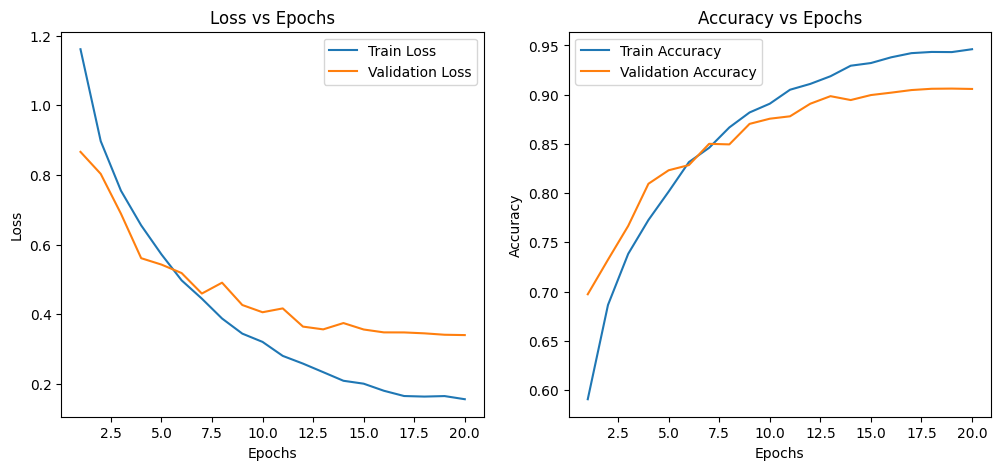

In [65]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

# Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.show()

In [66]:
#test
def Test(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [67]:
test_loss, test_acc = Test(
    model, test_loader, criterion, device
)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8974


In [68]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [28]:
import seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix

Classification Report:

                                                                    precision    recall  f1-score   support

Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.94      0.71      0.81       288
                                          Atopic Dermatitis Photos       0.90      0.97      0.93       123
                                                     Eczema Photos       0.89      0.94      0.91       309
                               Melanoma Skin Cancer Nevi and Moles       0.97      0.79      0.87       116
                                Nail Fungus and other Nail Disease       0.91      0.86      0.88       261
             Psoriasis pictures Lichen Planus and related diseases       0.89      0.90      0.89       352
                      Seborrheic Keratoses and other Benign Tumors       0.85      0.96      0.90       343
            Tinea Ringworm Candidiasis and other Fungal Infections       0.93      0.94      0.94       325
   

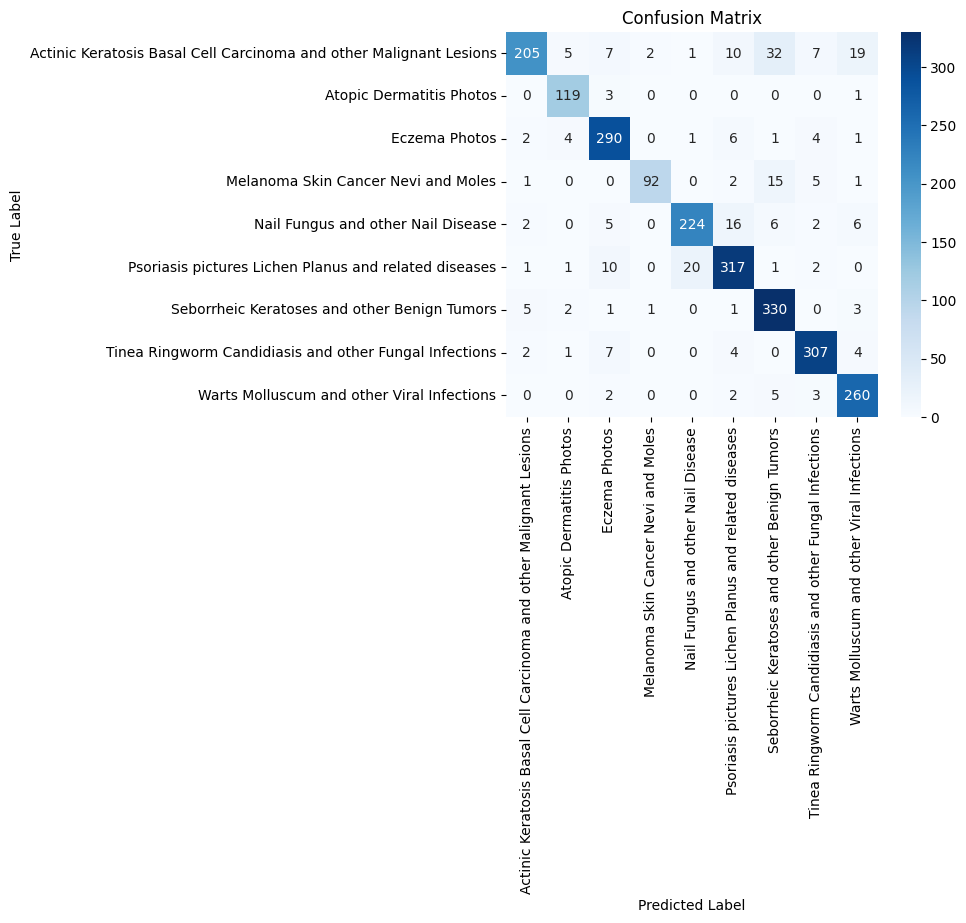

In [70]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# -------------------
# Confusion Matrix
# -------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()

In [76]:
classes = dataset.classes

In [30]:
classes

['Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions',
 'Atopic Dermatitis Photos',
 'Eczema Photos',
 'Melanoma Skin Cancer Nevi and Moles',
 'Nail Fungus and other Nail Disease',
 'Psoriasis pictures Lichen Planus and related diseases',
 'Seborrheic Keratoses and other Benign Tumors',
 'Tinea Ringworm Candidiasis and other Fungal Infections',
 'Warts Molluscum and other Viral Infections']

In [77]:
NUM_CLASSES=len(classes)

In [32]:
model = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)

in_features = model.head.in_features  # = 768

model.head = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 213MB/s] 


In [33]:
for p in model.parameters():
    p.requires_grad = True

In [34]:
EPOCHS=30

In [35]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,          # 🔥 small LR for full fine-tune
    weight_decay=1e-4
)

In [36]:
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler()

# lr = 1e-3
# optimizer = get_optimizer(model, lr)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)





In [37]:
def training(model, dataloader, optimizer, criterion, device, scaler, use_amp=True):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [38]:
def validation(model, dataloader, criterion, device):
   
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)  # sum over batch
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total  # average per sample
    acc = correct / total
    return avg_loss, acc

In [39]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [40]:
for epoch in range(EPOCHS):

    train_loss, train_acc = training(
        model, train_loader, optimizer, criterion, device, scaler
    )

    # Validation
    val_loss, val_acc = validation(
        model, val_loader, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"LR: {scheduler.get_last_lr()[0]:.6f}")
    print(f"Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

/tmp/ipykernel_55/1138730575.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Epoch 1
LR: 0.000100
Train Acc: 52.83% | Val Acc: 63.49%

Epoch 2
LR: 0.000100
Train Acc: 64.04% | Val Acc: 68.90%

Epoch 3
LR: 0.000100
Train Acc: 68.85% | Val Acc: 73.03%

Epoch 4
LR: 0.000100
Train Acc: 71.60% | Val Acc: 76.01%

Epoch 5
LR: 0.000100
Train Acc: 74.78% | Val Acc: 74.31%

Epoch 6
LR: 0.000100
Train Acc: 77.16% | Val Acc: 78.27%

Epoch 7
LR: 0.000010
Train Acc: 77.57% | Val Acc: 79.62%

Epoch 8
LR: 0.000010
Train Acc: 82.08% | Val Acc: 82.83%

Epoch 9
LR: 0.000010
Train Acc: 84.07% | Val Acc: 83.84%

Epoch 10
LR: 0.000010
Train Acc: 84.94% | Val Acc: 84.08%

Epoch 11
LR: 0.000010
Train Acc: 85.27% | Val Acc: 85.06%

Epoch 12
LR: 0.000010
Train Acc: 86.44% | Val Acc: 85.12%

Epoch 13
LR: 0.000010
Train Acc: 86.28% | Val Acc: 85.49%

Epoch 14
LR: 0.000001
Train Acc: 87.40% | Val Acc: 86.15%

Epoch 15
LR: 0.000001
Train Acc: 87.47% | Val Acc: 85.85%

Epoch 16
LR: 0.000001
Train Acc: 87.84% | Val Acc: 86.07%

Epoch 17
LR: 0.000001
Train Acc: 87.70% | Val Acc: 86.09%

Epoch

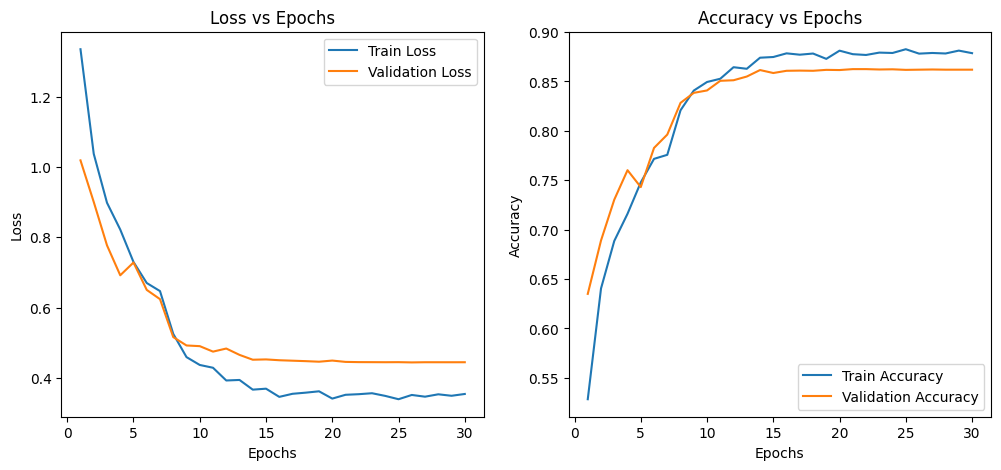

In [43]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

# Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.show()

In [89]:
#test
def Test(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [45]:
test_loss, test_acc = Test(
    model, test_loader, criterion, device
)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8342


In [46]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [50]:
class_names= dataset.classes

Classification Report:

                                                                    precision    recall  f1-score   support

Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.90      0.59      0.71       288
                                          Atopic Dermatitis Photos       0.81      0.92      0.86       123
                                                     Eczema Photos       0.81      0.88      0.84       309
                               Melanoma Skin Cancer Nevi and Moles       0.94      0.72      0.82       116
                                Nail Fungus and other Nail Disease       0.89      0.87      0.88       261
             Psoriasis pictures Lichen Planus and related diseases       0.81      0.80      0.80       352
                      Seborrheic Keratoses and other Benign Tumors       0.80      0.91      0.85       343
            Tinea Ringworm Candidiasis and other Fungal Infections       0.86      0.87      0.87       325
   

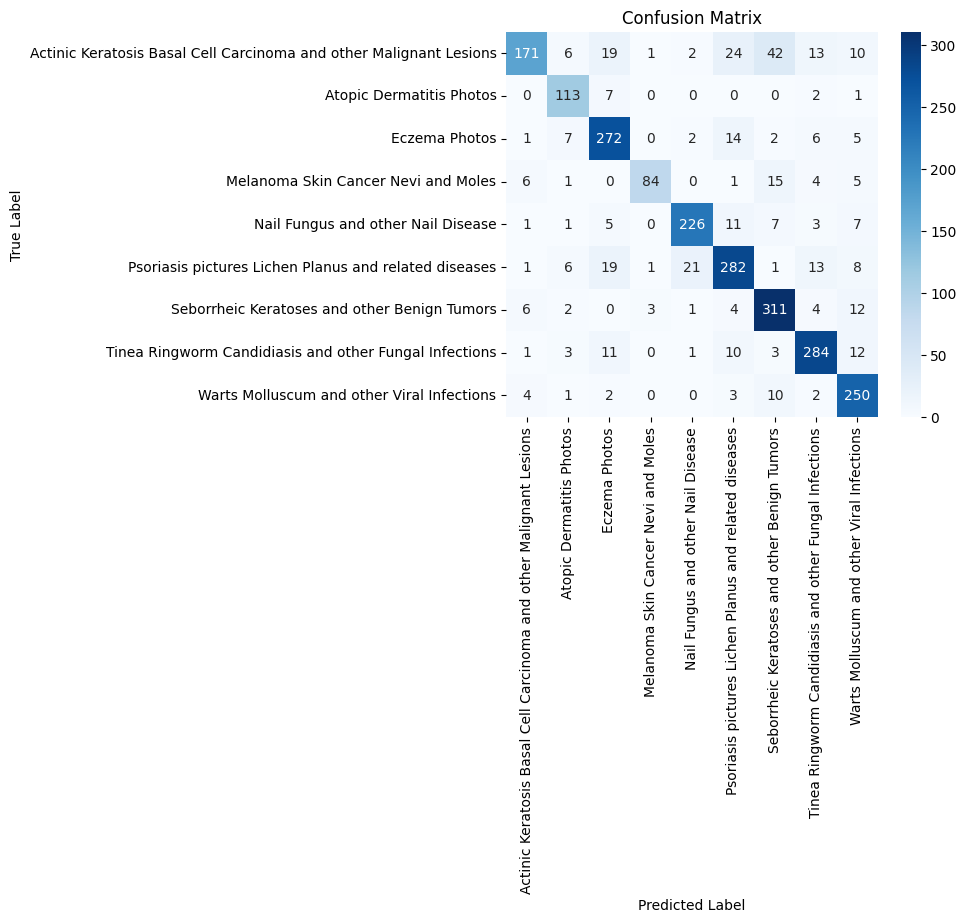

In [51]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# -------------------
# Confusion Matrix
# -------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()

In [52]:
#Densenet201

In [78]:
densenet = models.densenet201(weights=models.DenseNet201_Weights.DEFAULT)


Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:00<00:00, 143MB/s] 


In [79]:
in_features = densenet.classifier.in_features
densenet.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, NUM_CLASSES)
)
densenet = densenet.to(device)
for p in densenet.parameters():
    p.requires_grad = True

In [80]:
EPOCHS=20

In [81]:
optimizer = torch.optim.AdamW(
    densenet.parameters(),
    lr=1e-3,          # 🔥 small LR for full fine-tune
    weight_decay=1e-4
)

In [75]:
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler()

# lr = 1e-3
# optimizer = get_optimizer(model, lr)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)





In [82]:
criterion = nn.CrossEntropyLoss(weight=alpha)
scaler = torch.amp.GradScaler()

# lr = 1e-3
# optimizer = get_optimizer(model, lr)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

In [83]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [84]:
def training(model, dataloader, optimizer, criterion, device, scaler, use_amp=True):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [85]:
def validation(model, dataloader, criterion, device):
   
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)  # sum over batch
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total  # average per sample
    acc = correct / total
    return avg_loss, acc

In [86]:
for epoch in range(EPOCHS):

    train_loss, train_acc = training(
        densenet, train_loader, optimizer, criterion, device, scaler
    )

    # Validation
    val_loss, val_acc = validation(
        densenet, val_loader, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"LR: {scheduler.get_last_lr()[0]:.6f}")
    print(f"Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

/tmp/ipykernel_57/1138730575.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Epoch 1
LR: 0.001000
Train Acc: 33.94% | Val Acc: 44.82%

Epoch 2
LR: 0.001000
Train Acc: 43.99% | Val Acc: 51.60%

Epoch 3
LR: 0.001000
Train Acc: 48.19% | Val Acc: 48.69%

Epoch 4
LR: 0.001000
Train Acc: 51.09% | Val Acc: 54.43%

Epoch 5
LR: 0.001000
Train Acc: 51.20% | Val Acc: 50.94%

Epoch 6
LR: 0.001000
Train Acc: 54.45% | Val Acc: 58.11%

Epoch 7
LR: 0.001000
Train Acc: 56.47% | Val Acc: 56.42%

Epoch 8
LR: 0.001000
Train Acc: 57.27% | Val Acc: 58.39%

Epoch 9
LR: 0.001000
Train Acc: 57.69% | Val Acc: 58.84%

Epoch 10
LR: 0.000100
Train Acc: 59.62% | Val Acc: 58.77%

Epoch 11
LR: 0.000100
Train Acc: 63.71% | Val Acc: 65.33%

Epoch 12
LR: 0.000100
Train Acc: 65.24% | Val Acc: 66.97%

Epoch 13
LR: 0.000100
Train Acc: 65.97% | Val Acc: 67.36%

Epoch 14
LR: 0.000100
Train Acc: 66.98% | Val Acc: 68.75%

Epoch 15
LR: 0.000100
Train Acc: 67.66% | Val Acc: 68.24%

Epoch 16
LR: 0.000100
Train Acc: 68.23% | Val Acc: 67.72%

Epoch 17
LR: 0.000100
Train Acc: 68.74% | Val Acc: 69.73%

Epoch

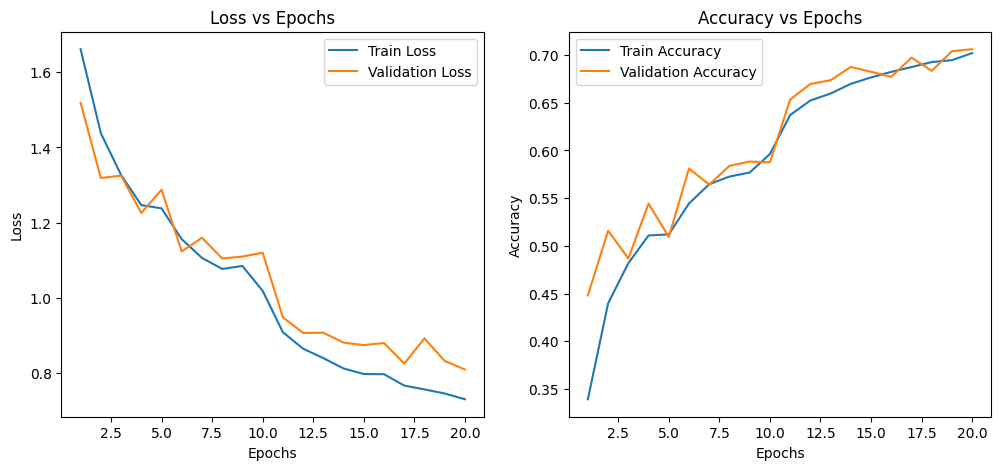

In [87]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

# Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.show()

In [90]:
test_loss, test_acc = Test(
    densenet, test_loader, criterion, device
)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.6111


In [91]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

NameError: name 'model' is not defined

In [92]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = densenet(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
from sklearn.metrics import *

In [93]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# -------------------
# Confusion Matrix
# -------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()

Classification Report:



NameError: name 'classification_report' is not defined

In [ ]:
#vgg19

In [84]:
vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 221MB/s] 


In [85]:
in_features = vgg.classifier[0].in_features  # 25088

vgg.classifier = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, NUM_CLASSES)
)
vgg=vgg.to(device)

In [86]:
for p in vgg.parameters():
    p.requires_grad = True

In [87]:
EPOCHS=30
optimizer = torch.optim.AdamW(
    vgg.parameters(),
    lr=1e-4,          # 🔥 small LR for full fine-tune
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler()

# lr = 1e-3
# optimizer = get_optimizer(model, lr)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)





In [89]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [90]:
for epoch in range(EPOCHS):

    train_loss, train_acc = training(
        vgg, train_loader, optimizer, criterion, device, scaler
    )

    # Validation
    val_loss, val_acc = validation(
        vgg, val_loader, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"LR: {scheduler.get_last_lr()[0]:.6f}")
    print(f"Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

/tmp/ipykernel_55/1138730575.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Epoch 1
LR: 0.000100
Train Acc: 42.10% | Val Acc: 51.43%

Epoch 2
LR: 0.000100
Train Acc: 52.50% | Val Acc: 55.26%

Epoch 3
LR: 0.000100
Train Acc: 55.93% | Val Acc: 55.22%

Epoch 4
LR: 0.000100
Train Acc: 58.81% | Val Acc: 60.42%

Epoch 5
LR: 0.000100
Train Acc: 60.51% | Val Acc: 63.23%

Epoch 6
LR: 0.000100
Train Acc: 62.61% | Val Acc: 67.00%

Epoch 7
LR: 0.000010
Train Acc: 63.99% | Val Acc: 64.81%

Epoch 8
LR: 0.000010
Train Acc: 69.70% | Val Acc: 70.18%

Epoch 9
LR: 0.000010
Train Acc: 70.87% | Val Acc: 70.70%

Epoch 10
LR: 0.000010
Train Acc: 71.92% | Val Acc: 71.32%

Epoch 11
LR: 0.000010
Train Acc: 72.63% | Val Acc: 71.57%

Epoch 12
LR: 0.000010
Train Acc: 73.44% | Val Acc: 72.41%

Epoch 13
LR: 0.000010
Train Acc: 73.88% | Val Acc: 73.01%

Epoch 14
LR: 0.000001
Train Acc: 73.62% | Val Acc: 73.80%

Epoch 15
LR: 0.000001
Train Acc: 74.12% | Val Acc: 73.42%

Epoch 16
LR: 0.000001
Train Acc: 74.83% | Val Acc: 73.74%

Epoch 17
LR: 0.000001
Train Acc: 75.12% | Val Acc: 73.82%

Epoch

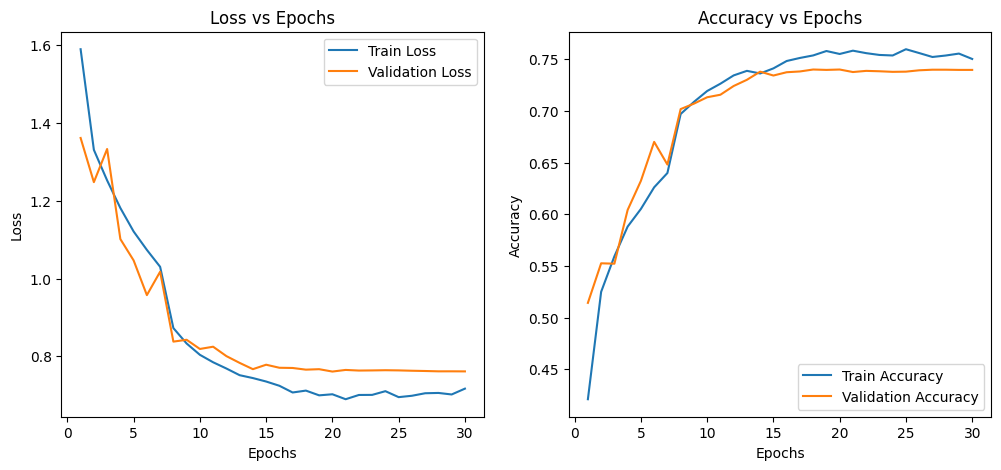

In [91]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

# Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.show()

In [92]:
test_loss, test_acc = Test(
    vgg, test_loader, criterion, device
)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.6597


In [97]:
all_preds = []
all_labels = []

In [98]:


with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vgg(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Classification Report:

                                                                    precision    recall  f1-score   support

Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.85      0.32      0.46       288
                                          Atopic Dermatitis Photos       0.60      0.80      0.69       123
                                                     Eczema Photos       0.64      0.66      0.65       309
                               Melanoma Skin Cancer Nevi and Moles       0.88      0.45      0.59       116
                                Nail Fungus and other Nail Disease       0.93      0.85      0.89       261
             Psoriasis pictures Lichen Planus and related diseases       0.61      0.60      0.60       352
                      Seborrheic Keratoses and other Benign Tumors       0.54      0.78      0.64       343
            Tinea Ringworm Candidiasis and other Fungal Infections       0.66      0.68      0.67       325
   

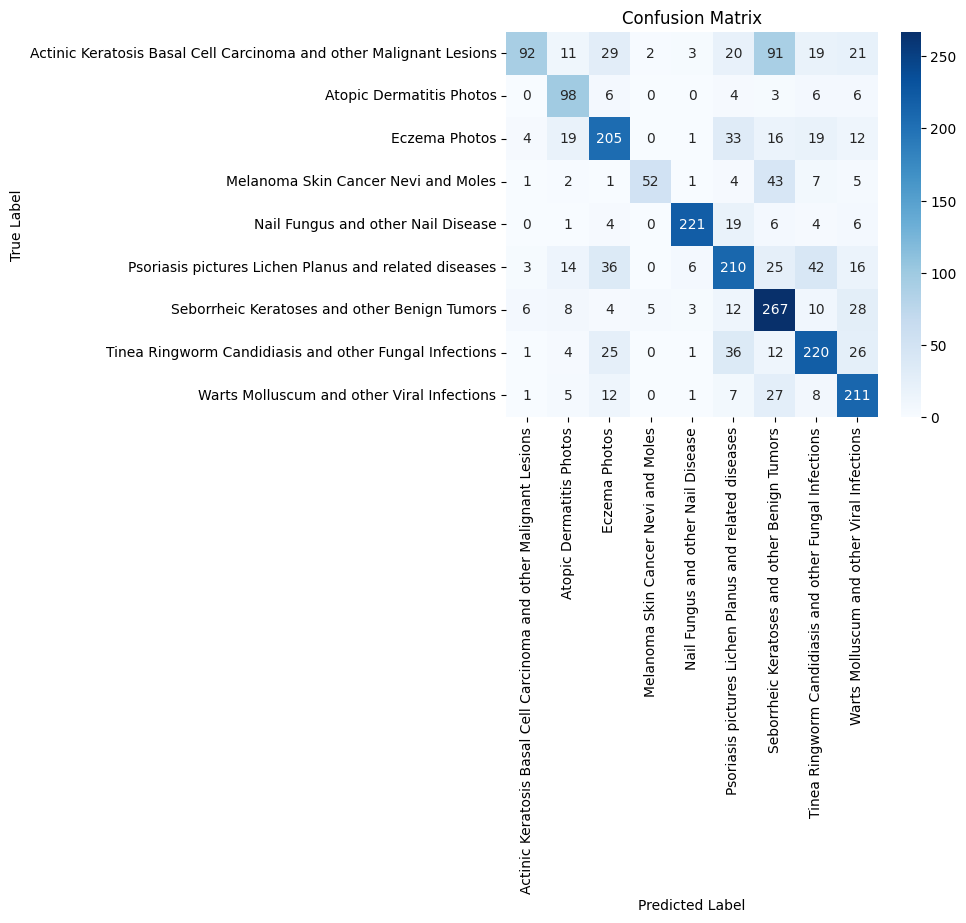

In [99]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# -------------------
# Confusion Matrix
# -------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()

In [100]:
#ViT

In [32]:
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 197MB/s] 


In [33]:
in_features = vit.heads.head.in_features  # usually 768

vit.heads.head = nn.Sequential(
    nn.LayerNorm(in_features),
    nn.Dropout(p=0.5),          # 🔥 dropout added
    nn.Linear(in_features, NUM_CLASSES)
)
vit=vit.to(device)

In [34]:
for p in vit.parameters():
    p.requires_grad = True

In [35]:
def training(model, dataloader, optimizer, criterion, device, scaler, use_amp=True):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [36]:
def validation(model, dataloader, criterion, device):
   
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)  # sum over batch
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total  # average per sample
    acc = correct / total
    return avg_loss, acc

In [37]:
EPOCHS=30
optimizer = torch.optim.AdamW(
    vit.parameters(),
    lr=1e-4,          # 🔥 small LR for full fine-tune
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler()

# lr = 1e-3
# optimizer = get_optimizer(model, lr)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)





In [38]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [39]:
for epoch in range(EPOCHS):

    train_loss, train_acc = training(
        vit, train_loader, optimizer, criterion, device, scaler
    )

    # Validation
    val_loss, val_acc = validation(
        vit, val_loader, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"LR: {scheduler.get_last_lr()[0]:.6f}")
    print(f"Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

/tmp/ipykernel_55/1138730575.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Epoch 1
LR: 0.000100
Train Acc: 52.73% | Val Acc: 62.86%

Epoch 2
LR: 0.000100
Train Acc: 63.96% | Val Acc: 67.72%

Epoch 3
LR: 0.000100
Train Acc: 68.72% | Val Acc: 73.10%

Epoch 4
LR: 0.000100
Train Acc: 73.39% | Val Acc: 75.88%

Epoch 5
LR: 0.000100
Train Acc: 76.43% | Val Acc: 74.92%

Epoch 6
LR: 0.000100
Train Acc: 78.49% | Val Acc: 76.35%

Epoch 7
LR: 0.000010
Train Acc: 80.45% | Val Acc: 77.82%

Epoch 8
LR: 0.000010
Train Acc: 86.85% | Val Acc: 84.14%

Epoch 9
LR: 0.000010
Train Acc: 89.16% | Val Acc: 85.49%

Epoch 10
LR: 0.000010
Train Acc: 90.22% | Val Acc: 85.87%

Epoch 11
LR: 0.000010
Train Acc: 90.56% | Val Acc: 86.20%

Epoch 12
LR: 0.000010
Train Acc: 91.23% | Val Acc: 86.69%

Epoch 13
LR: 0.000010
Train Acc: 91.55% | Val Acc: 86.75%

Epoch 14
LR: 0.000001
Train Acc: 92.08% | Val Acc: 87.69%

Epoch 15
LR: 0.000001
Train Acc: 92.71% | Val Acc: 88.08%

Epoch 16
LR: 0.000001
Train Acc: 92.97% | Val Acc: 87.84%

Epoch 17
LR: 0.000001
Train Acc: 93.23% | Val Acc: 88.08%

Epoch

KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (30,) and (28,)

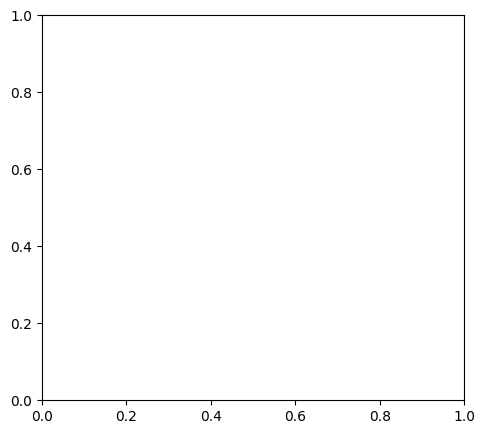

In [41]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

# Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.show()

In [ ]:
test_loss, test_acc = Test(
    vgg, test_loader, criterion, device
)

print(f"Test Accuracy: {test_acc:.4f}")

In [ ]:
all_preds = []
all_labels = []

In [ ]:


with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vgg(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# -------------------
# Confusion Matrix
# -------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#resnet50

In [ ]:
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
in_features = resnet.fc.in_features  # 2048

resnet.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, NUM_CLASSES)
)

In [ ]:
for p in resnet.parameters():
    p.requires_grad = True

In [ ]:
EPOCHS=30
optimizer = torch.optim.AdamW(
    resnet.parameters(),
    lr=1e-4,          # 🔥 small LR for full fine-tune
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler()

# lr = 1e-3
# optimizer = get_optimizer(model, lr)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=7,
    gamma=0.1
)





In [ ]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [ ]:
for epoch in range(EPOCHS):

    train_loss, train_acc = training(
        resnet, train_loader, optimizer, criterion, device, scaler
    )

    # Validation
    val_loss, val_acc = validation(
        resnet, val_loader, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"LR: {scheduler.get_last_lr()[0]:.6f}")
    print(f"Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

# Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.show()

In [ ]:
test_loss, test_acc = Test(
    resnet, test_loader, criterion, device
)

print(f"Test Accuracy: {test_acc:.4f}")

In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# -------------------
# Confusion Matrix
# -------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()